In [14]:
#Customized CNN
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras import models, layers
from tensorflow.keras.layers import BatchNormalization, Dropout
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.preprocessing.image import ImageDataGenerator #Creates new variations of images
from tensorflow.keras.callbacks import ReduceLROnPlateau #Lowers the learning rate
from tensorflow.keras.layers import BatchNormalization, Dropout

In [6]:
(Data_1, Data_2), (Test_Data1, Test_Data2) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3212s 19us/step


In [7]:
class_names = [
    "Airplane",
    "Automobile",
    "Bird",
    "Cat",
    "Deer",
    "Dog",
    "Frog",
    "Horse",
    "Ship",
    "Truck"
]

In [8]:
Data_1 = Data_1.astype("float32") / 255.0 #Image pixels are converted to float from integers (Normalisation of training data)
Test_Data1 = Test_Data1.astype("float32") / 255.0 #Normalisation of Testing data

In [9]:
Data_1, Data1_val, Data_2, Data2_val = train_test_split (
    Data_1,
    Data_2,
    test_size=0.1, #10% of the training data is used as the validation set
    random_state=42, #Fixs the random split
    stratify=Data_2 #Keeps Class distribution balanced
)#Splits 1 dataset into 2 parts

In [12]:
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen.fit(Data_1) #Data Augmentation

In [17]:
model = models.Sequential()
# First layer
model.add(layers.Conv2D(
    64,
    (3,3),
    padding='same',
    activation='relu',
    input_shape=(32,32,3)
))
model.add(BatchNormalization())
model.add(layers.Conv2D(64,(3,3),padding='same',activation='relu'))
model.add(BatchNormalization())
model.add(layers.MaxPooling2D((2,2)))
model.add(Dropout(0.25))
# Second layer
model.add(layers.Conv2D(128,(3,3),padding='same',activation='relu'))
model.add(BatchNormalization())
model.add(layers.Conv2D(128,(3,3),padding='same',activation='relu'))
model.add(BatchNormalization())
model.add(layers.MaxPooling2D((2,2)))
model.add(Dropout(0.25))
# Fully Connected Layers
model.add(layers.Flatten())
model.add(layers.Dense(256,activation='relu'))
model.add(Dropout(0.5))
model.add(layers.Dense(10,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
) #Compile

In [19]:
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1
) #Learning rate scheduler

In [21]:
history = model.fit(
    datagen.flow(Data_1, Data_2, batch_size=64),
    epochs=20,
    validation_data=(Data1_val, Data2_val),
    callbacks=[lr_scheduler]
) #Training

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 788s 1s/step - accuracy: 0.3220 - loss: 1.8858 - val_accuracy: 0.4742 - val_loss: 1.4201 - learning_rate: 0.0010
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 778s 1s/step - accuracy: 0.4457 - loss: 1.5141 - val_accuracy: 0.5644 - val_loss: 1.2322 - learning_rate: 0.0010
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 775s 1s/step - accuracy: 0.5185 - loss: 1.3408 - val_accuracy: 0.5142 - val_loss: 1.4229 - learning_rate: 0.0010
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 776s 1s/step - accuracy: 0.5665 - loss: 1.2279 - val_accuracy: 0.5348 - val_loss: 1.5163 - learning_rate: 0.0010
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 762s 1s/step - accuracy: 0.5956 - loss: 1.1499 - val_accuracy: 0.6856 - val_loss: 0.9149 - learning_rate: 0.0010
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 761s 1s/step - accuracy: 0.6282 - loss: 1.0839 - val_accuracy: 0.6824 - val_loss: 0.9286 - learning_rate: 0.0010
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 758s 1s/step - accuracy: 0.6511 - loss: 1.

In [24]:
Test_loss, Test_accuracy = model.evaluate(Test_Data1, Test_Data2)
print("Test Loss:", Test_loss)
print("Test Accuracy:", Test_accuracy) #Evalution step

313/313 ━━━━━━━━━━━━━━━━━━━━ 39s 126ms/step - accuracy: 0.8060 - loss: 0.5884
Test Loss: 0.5884415507316589
Test Accuracy: 0.8059999942779541


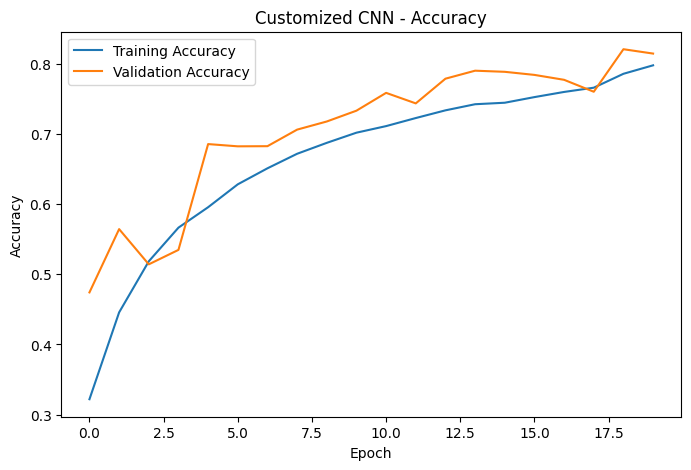

In [25]:
#Ploting for Training and Accuracy
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Customized CNN - Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

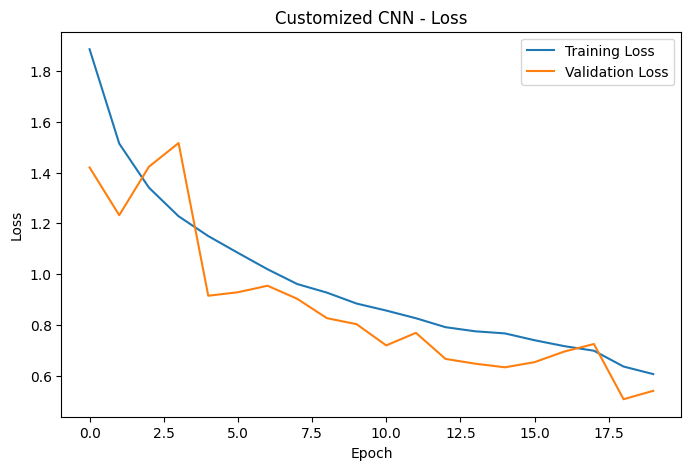

In [26]:
#Ploting Training and Loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Customized CNN - Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [28]:
#Predict classes
Data2_pro = model.predict(Test_Data1)
Data2_pro_classes = np.argmax(Data2_pro, axis=1)
Data2_true = Test_Data2.flatten()
#Classification Report
print(classification_report(
    Data2_true,
    Data2_pro_classes,
    target_names=class_names
))

313/313 ━━━━━━━━━━━━━━━━━━━━ 45s 143ms/step
              precision    recall  f1-score   support

    Airplane       0.78      0.88      0.83      1000
  Automobile       0.91      0.94      0.92      1000
        Bird       0.80      0.69      0.74      1000
         Cat       0.75      0.56      0.64      1000
        Deer       0.81      0.75      0.78      1000
         Dog       0.90      0.58      0.70      1000
        Frog       0.71      0.94      0.81      1000
       Horse       0.72      0.93      0.81      1000
        Ship       0.94      0.86      0.90      1000
       Truck       0.84      0.93      0.88      1000

    accuracy                           0.81     10000
   macro avg       0.81      0.81      0.80     10000
weighted avg       0.81      0.81      0.80     10000



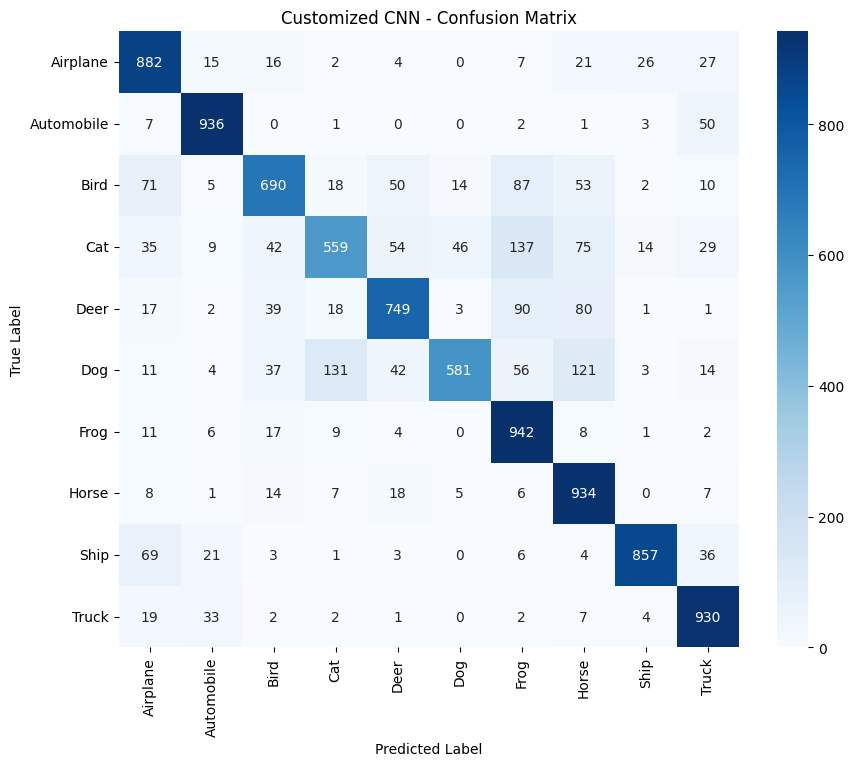

In [29]:
#Confusion Matrix
CM = confusion_matrix(Data2_true, Data2_pro_classes)
plt.figure(figsize=(10,8))
sns.heatmap(
    CM,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Customized CNN - Confusion Matrix")
plt.show()

In [30]:
model.save("customized_cnn.keras") #Saved
print("Customized CNN model saved successfully!")

Customized CNN model saved successfully!
